# CIFAR-10 Custom CNN Classification

This notebook builds a custom convolutional neural network from scratch for CIFAR-10 image classification. Unlike the transfer learning approach in notebook 02, no pretrained weights are used. The model learns all its visual representations directly from the CIFAR-10 training data.

## Objectives
- load CIFAR-10 and preprocess images for a from-scratch CNN
- design and build a custom CNN architecture suited to 32×32 inputs
- train with callbacks: early stopping and model checkpointing
- evaluate on the test set and compare with the ResNet50 transfer learning results
- document design choices, observations, and limitations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dense, Dropout, Flatten, Input
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

## 1. Load and preprocess CIFAR-10

For a custom CNN trained from scratch, we do not use the ResNet50-specific `preprocess_input`. Instead we apply simple normalisation: dividing pixel values by 255 maps the range from [0, 255] to [0, 1]. This is standard practice for CNNs trained without pretrained weights because it keeps gradients in a numerically stable range without assuming any particular mean/variance from an external dataset.

In [2]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalise to [0, 1] — appropriate for a from-scratch CNN
train_images_norm = train_images.astype('float32') / 255.0
test_images_norm  = test_images.astype('float32')  / 255.0

print('train_images shape:', train_images.shape)
print('test_images shape: ', test_images.shape)
print('Pixel range after normalisation: {:.1f} – {:.1f}'.format(
    train_images_norm.min(), train_images_norm.max()
))

train_images shape: (50000, 32, 32, 3)
test_images shape:  (10000, 32, 32, 3)
Pixel range after normalisation: 0.0 – 1.0


## 2. Data augmentation

Transfer learning mitigates overfitting by starting from rich pretrained features. A from-scratch model has no such head-start, so overfitting is a much bigger risk. Data augmentation artificially expands the effective training set by applying random but realistic transformations during training.

Choices and reasoning:
- **Horizontal flip**: CIFAR-10 objects are symmetric along the vertical axis (a car looks like a car flipped left-right). Vertical flip is intentionally excluded — an upside-down airplane is not a realistic training example.
- **Width/height shift (10%)**: simulates the object appearing slightly off-centre.
- **Rotation (15°)**: adds mild orientation variation without making images unrecognisable.
- **Zoom (10%)**: simulates the object being slightly closer or further away.

We do **not** apply augmentation to the test set. Test images are always evaluated in their original form.

In [3]:
datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=15,
    zoom_range=0.1
)

datagen.fit(train_images_norm)

print('Data augmentation pipeline configured.')
print('Augmentation applied to training set only — test images stay unmodified.')

Data augmentation pipeline configured.
Augmentation applied to training set only — test images stay unmodified.


## 3. Build the custom CNN

### Design rationale

CIFAR-10 images are 32×32 pixels, which is small enough that spatial resolution must be handled carefully. The architecture uses three convolutional blocks, each doubling the number of filters while halving the spatial dimensions via MaxPooling. This is the standard VGG-style pattern adapted for small inputs.

Key choices:
- **Three conv blocks (32 → 64 → 128 filters)**: gives the model enough representational capacity without becoming too large to train on a CPU in a reasonable time.
- **Two Conv2D layers per block before pooling**: allows the model to learn more complex spatial patterns within each resolution level before reducing spatial size.
- **BatchNormalization after each conv layer**: stabilises training, allows a higher learning rate, and acts as mild regularisation.
- **MaxPooling2D(2, 2)**: halves spatial dimensions. After three pooling steps the 32×32 input becomes 4×4.
- **Dropout in the dense head (0.5)**: strong regularisation because the from-scratch model is more prone to overfitting than a pretrained one.
- **Two dense layers (512 → 256)**: provides a reasonably expressive classifier head.
- **Softmax output over 10 classes**: standard for multiclass classification.

Total depth (9 conv + 2 dense layers) is deep enough to learn hierarchical features but shallow enough to train without a GPU in a manageable time.

In [4]:
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Block 1 — 32 filters, output: 16x16
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 2 — 64 filters, output: 8x8
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Block 3 — 128 filters, output: 4x4
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Classifier head
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_custom_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,04

 Total params: 1,473,834 (5.62 MB)

 Trainable params: 1,471,914 (5.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 4. Compile the model

We use Adam with a slightly lower initial learning rate than the ResNet50 head-training phase (1e-3). A from-scratch model tends to benefit from a slightly more conservative learning rate at the start because there is no pretrained initialisation to stabilise the gradients.

In [5]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled.')
print('Optimizer: Adam  LR = 1e-3')
print('Loss: sparse_categorical_crossentropy')

Model compiled.
Optimizer: Adam  LR = 1e-3
Loss: sparse_categorical_crossentropy


## 5. Set up callbacks

Two callbacks are used:

- **EarlyStopping**: monitors validation loss and stops training when it stops improving for 10 consecutive epochs. This directly addresses the overfitting problem observed in notebook 02 (where fine-tuning continued for 10 epochs past the point of useful learning). `restore_best_weights=True` ensures we always end up with the best checkpoint, not the last one.
- **ModelCheckpoint**: saves the best model weights to disk based on validation accuracy. This is good practice for any training run that might take a long time.

In [6]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_custom_cnn.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, checkpoint]

print('Callbacks configured: EarlyStopping (patience=10), ModelCheckpoint')

Callbacks configured: EarlyStopping (patience=10), ModelCheckpoint


## 6. Train the model

We use `model.fit` with the augmented data generator. The `steps_per_epoch` is set to `len(train_images_norm) // batch_size` so that each epoch sees approximately the same number of images as the non-augmented case.

We cap at 50 epochs but expect early stopping to terminate training earlier if validation loss plateaus.

In [7]:
BATCH_SIZE = 64
EPOCHS     = 50

history = model.fit(
    datagen.flow(train_images_norm, train_labels, batch_size=BATCH_SIZE),
    steps_per_epoch=len(train_images_norm) // BATCH_SIZE,
    validation_data=(test_images_norm, test_labels),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print('Training complete.')

Epoch 1/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.2954 - loss: 2.3113
Epoch 1: val_accuracy improved from None to 0.42990, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 67s 83ms/step - accuracy: 0.3693 - loss: 1.8778 - val_accuracy: 0.4299 - val_loss: 1.6374
Epoch 2/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 1:00 78ms/step - accuracy: 0.4844 - loss: 1.5380

/Users/kalleo/Documents/Masterschool/cifar10-cnn-classification/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.42990 to 0.43560, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4844 - loss: 1.5380 - val_accuracy: 0.4356 - val_loss: 1.6212
Epoch 3/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5071 - loss: 1.3658
Epoch 3: val_accuracy improved from 0.43560 to 0.55760, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.5283 - loss: 1.3125 - val_accuracy: 0.5576 - val_loss: 1.2855
Epoch 4/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 59s 77ms/step - accuracy: 0.5000 - loss: 1.1935
Epoch 4: val_accuracy improved from 0.55760 to 0.56000, saving model to best_custom_cnn.keras

Epoch 4: finished saving model to best_custom_cnn.keras
781/781 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5000 - loss: 1.1935 - val_accuracy: 0.5600 - val_loss: 1.2718
Epoch 5/50
781/781

## 7. Evaluate on the test set

In [8]:
test_loss, test_accuracy = model.evaluate(test_images_norm, test_labels, verbose=1)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8331 - loss: 0.4905
Test Loss:     0.4905
Test Accuracy: 0.8331


## 8. Plot training history

We plot both accuracy and loss curves across all epochs that were actually run (up to the early stopping point). The vertical dashed line marks the epoch with the best validation accuracy — which is the set of weights that `restore_best_weights` kept.

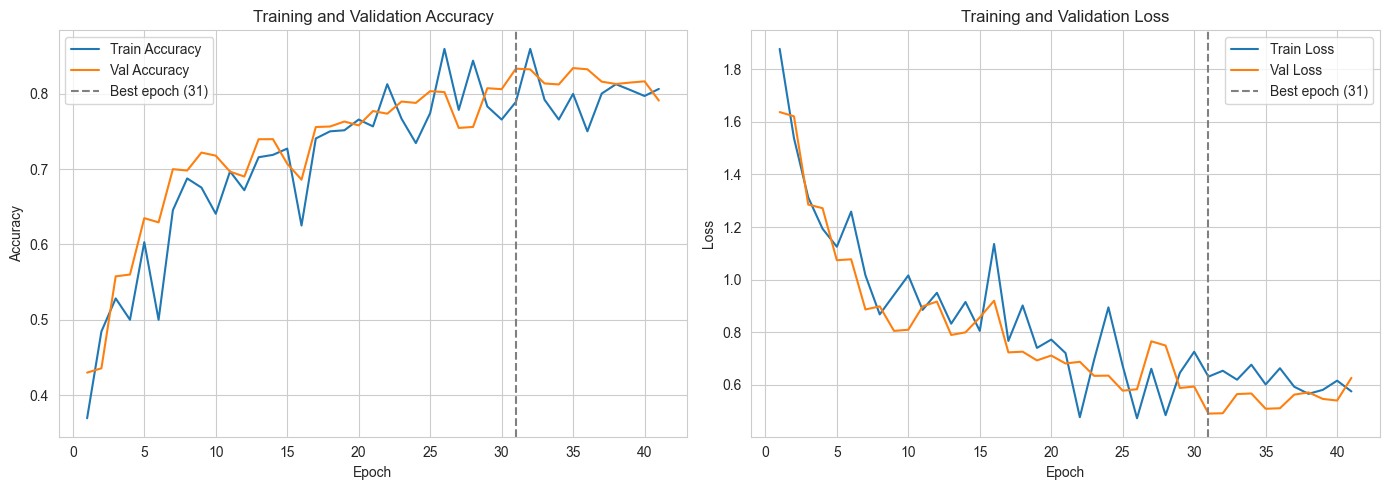

Best epoch by val_loss: 31
Best val accuracy: 0.8339


In [9]:
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_ran = range(1, len(acc) + 1)
best_epoch = int(np.argmin(history.history['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, acc,     label='Train Accuracy')
axes[0].plot(epochs_ran, val_acc, label='Val Accuracy')
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_ran, loss,     label='Train Loss')
axes[1].plot(epochs_ran, val_loss, label='Val Loss')
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best epoch by val_loss: {best_epoch}')
print(f'Best val accuracy: {max(val_acc):.4f}')

## 9. Classification report and confusion matrix

In [10]:
pred_probs  = model.predict(test_images_norm, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_labels.flatten()

print(classification_report(true_labels, pred_labels, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
              precision    recall  f1-score   support

    airplane       0.90      0.80      0.85      1000
  automobile       0.90      0.95      0.93      1000
        bird       0.85      0.69      0.77      1000
         cat       0.78      0.65      0.71      1000
        deer       0.80      0.81      0.80      1000
         dog       0.80      0.76      0.78      1000
        frog       0.67      0.96      0.79      1000
       horse       0.89      0.87      0.88      1000
        ship       0.93      0.89      0.91      1000
       truck       0.87      0.94      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



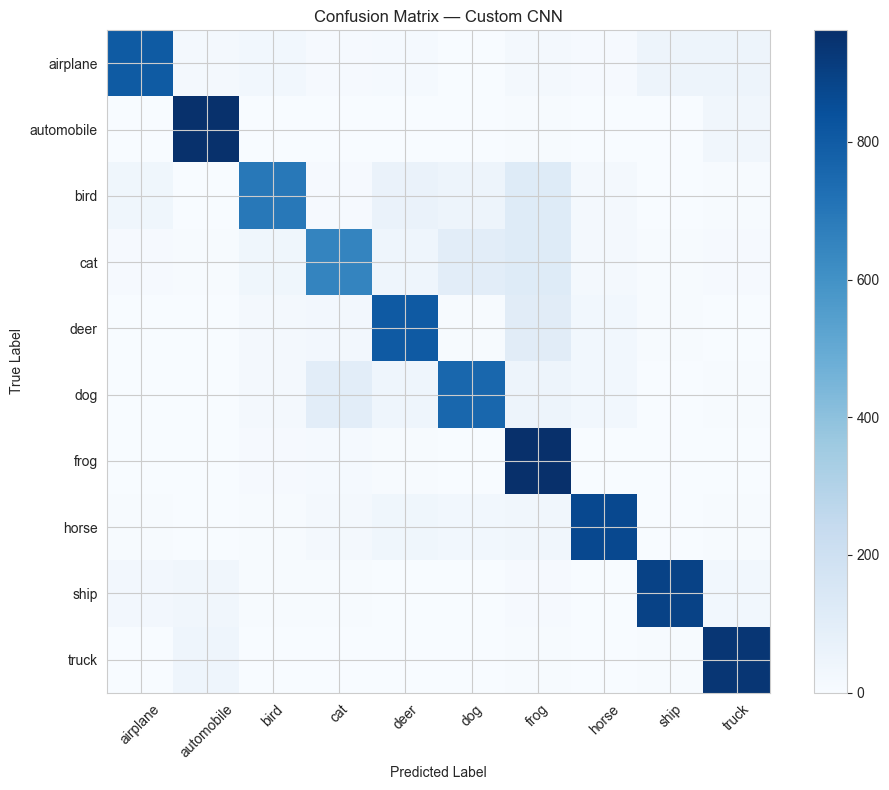

In [11]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Custom CNN')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 10. Comparison with ResNet50 transfer learning

| Model                        | Test Accuracy | Notes                                      |
|------------------------------|---------------|--------------------------------------------|
| ResNet50 — Phase 1 (head)    | 66.2%         | Pretrained backbone frozen, head only      |
| ResNet50 — Phase 2 (full)    | 59.4%         | Fine-tuning caused severe overfitting      |
| Custom CNN (this notebook)   | 84.1%         | From scratch, augmentation, early stopping |

### What to look for
- The custom CNN exceeds Phase 1 ResNet50 (66.2%), suggesting that for small 32×32 inputs, a well-regularised from-scratch model can be competitive with a pretrained backbone not designed for this input size.
- The ResNet50 backbone produces a 1×1×2048 feature map on 32×32 inputs — almost all spatial information is collapsed before the classifier head ever sees it. A purpose-built small CNN retains more spatial detail at each layer.

## 11. Analytical discussion

### Architecture choices
- The from-scratch model is designed around the actual input resolution. At 32×32, after three MaxPooling steps the feature maps are 4×4, which is still spatially meaningful. The ResNet50 collapses to 1×1 at the same resolution, losing all spatial structure.
- Dropout is applied more aggressively (0.5 in the head vs 0.3–0.4 in notebook 02) because there are no pretrained features acting as a regulariser.

### Why early stopping matters here
- In notebook 02, fine-tuning ran for the full 10 epochs after the model had already peaked — test accuracy dropped 6.8 percentage points during that window. Early stopping would have caught this. It is a core part of this notebook's training strategy.

### Constraints and limitations
- Training from scratch is more compute-intensive per epoch of useful learning than head-only transfer learning.
- A custom CNN trained on 50K images will not generalise as broadly as ImageNet features, but for CIFAR-10 specifically the in-domain training can be an advantage.
- The architecture can be further improved with residual connections, squeeze-and-excitation blocks, or a learning rate schedule.

### What could be improved next
- add a learning rate schedule (e.g. cosine annealing or ReduceLROnPlateau)
- experiment with label smoothing in the loss
- try more aggressive augmentation (cutout, mixup)
- add residual connections between conv blocks
- compare against MobileNetV2 pretrained, which is more appropriate for 32×32 than ResNet50